# MINLP Algorithms

Integer programs are easy to write and hard to solve. The handout on *Integer Programming Algorithms*
makes the point with one table: complete enumeration of 35 binary variables takes about 110 years at a
tenth of a second per LP, and the Sudoku model from two lectures ago has 513 of them. Every algorithm in
this notebook exists to skip almost all of that search space and **prove** that nothing was lost.

This notebook is the computational companion to that handout. It does not re-derive the theory — the
handout does that — it runs the two algorithms and shows you what they look like from the inside:

1. **Branch and bound**, as a loop rather than as nine cells of hand-fixed variables, on the handout's
   worked example. The output is the search tree.
2. **Outer approximation**, implemented from the handout's flowchart — an NLP subproblem for the upper
   bound, an MILP master problem for the lower bound, integer cuts, and a gap that has to close — on a
   convex MINLP for the design of multilayer building insulation.

:::{note}
The companion notebook [](../8/MILP.ipynb) walks the same branch and bound example node by node, one cell
per node. Read that first if you want to see each LP relaxation on its own. Here the point is the
algorithm, not the nodes.
:::

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 1 rewritten and 25 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

helper.set_plotting_style()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

# House figure style. On Colab only the notebook is present, so fall back to the raw URL.
STYLE = (
    "https://raw.githubusercontent.com/ndcbe/optimization/main/figures/dowling.mplstyle"
    if "google.colab" in sys.modules
    else "../../figures/dowling.mplstyle"
)
plt.style.use(STYLE)

solver_milp = pyo.SolverFactory("appsi_highs")
solver_nlp = pyo.SolverFactory("ipopt")

## 1. Branch and bound

$$
\begin{aligned}
\min_{x,\,y} \quad & z = x + y_1 + 3y_2 + 2y_3 \\
\text{s.t.} \quad & -x + 3y_1 + 2y_2 + y_3 \le 0 \\
                  & -5y_1 - 8y_2 - 3y_3 \le -9 \\
                  & x \ge 0, \qquad y \in \{0,1\}^{3}
\end{aligned}
$$

This is problem (MIPEX) from Biegler, Grossmann & Westerberg (1997), §A.3.2, p. 760, and the tree we
build below is their Figure A.10.

The handout's algorithm, in three cases. At each node solve the LP relaxation, then:

* **case 1** — the LP is infeasible, or its value already exceeds the incumbent: *fathom* the node and
  everything below it;
* **case 2** — the LP solution is integral: it is optimal for that subtree, so record it as the incumbent
  and stop descending;
* **case 3** — otherwise, branch on a fractional variable.

Only case 3 grows the tree. The efficiency of the whole method is the proportion of nodes settled by
cases 1 and 2.

In [3]:
def build_mipex_relaxation(fixed=None):
    """LP relaxation of (MIPEX) with some binaries fixed.

    Arguments:
        fixed: dict mapping binary index (1, 2, 3) to the value it is fixed at

    Returns:
        a Pyomo ConcreteModel
    """
    m = pyo.ConcreteModel("MIPEX LP relaxation")
    m.J = pyo.RangeSet(1, 3)

    m.x = pyo.Var(domain=pyo.NonNegativeReals)
    m.y = pyo.Var(m.J, bounds=(0, 1))  # integrality relaxed to the unit box

    @m.Constraint()
    def coupling(m):
        return -m.x + 3 * m.y[1] + 2 * m.y[2] + m.y[3] <= 0

    @m.Constraint()
    def covering(m):
        return -5 * m.y[1] - 8 * m.y[2] - 3 * m.y[3] <= -9

    @m.Objective(sense=pyo.minimize)
    def z(m):
        return m.x + m.y[1] + 3 * m.y[2] + 2 * m.y[3]

    for j, value in (fixed or {}).items():
        m.y[j].fix(value)

    return m


def solve_node(fixed):
    """Solve one node's LP relaxation and report what happened.

    An infeasible relaxation is an ANSWER here, not a failure -- it fathoms a whole
    subtree. So the termination condition is checked explicitly and `load_solutions`
    is deferred: HiGHS raises if asked to load a solution that does not exist.
    """
    m = build_mipex_relaxation(fixed)
    results = solver_milp.solve(m, load_solutions=False)
    tc = results.solver.termination_condition

    if pyo.check_optimal_termination(results):
        m.solutions.load_from(results)
        return {
            "status": "optimal",
            "z": pyo.value(m.z),
            "y": np.array([pyo.value(m.y[j]) for j in m.J]),
            "x": pyo.value(m.x),
        }
    if tc in (
        pyo.TerminationCondition.infeasible,
        pyo.TerminationCondition.infeasibleOrUnbounded,
    ):
        return {"status": "infeasible", "z": None, "y": None, "x": None}

    raise RuntimeError(f"unexpected termination condition at node {fixed}: {tc}")

### The search

The handout works **breadth first** — every node of one level before descending — matching BGW's Figure
A.10. A breadth-first traversal is a **FIFO queue** of active nodes: `pop(0)` takes the oldest, and
children are appended to the back. Change that one line to `pop()` and you have depth first.

In [4]:
INT_TOL = 1e-6


def branch_and_bound(verbose=True):
    """Breadth-first branch and bound on (MIPEX).

    Returns:
        nodes: list of dicts, one per node, in the order the LPs were solved
        edges: list of (parent, child, label) tuples describing the tree
        incumbent: dict with the optimal solution
    """
    incumbent_z, incumbent = np.inf, None
    queue = [{"fixed": {}, "parent": None, "label": ""}]  # FIFO -> breadth first
    nodes, edges = [], []
    node_id = 0

    while queue:
        node = queue.pop(0)
        node_id += 1
        result = solve_node(node["fixed"])
        if node["parent"] is not None:
            edges.append((node["parent"], node_id, node["label"]))

        record = {
            "node": node_id,
            "fixed": ", ".join(f"y{j}={v}" for j, v in node["fixed"].items()) or "--",
            "z_LP": result["z"],
            "y_LP": None if result["y"] is None else np.round(result["y"], 4),
        }

        # case 1a: the relaxation has no feasible point, so neither does the subtree
        if result["status"] == "infeasible":
            record.update(case=1, outcome="infeasible -> fathom")

        # case 1b: the bound is already worse than a solution we hold in hand
        elif result["z"] > incumbent_z - INT_TOL:
            record.update(
                case=1, outcome=f"bound {result['z']:.2f} >= incumbent -> fathom"
            )

        else:
            fractional = [
                j
                for j in (1, 2, 3)
                if abs(result["y"][j - 1] - round(result["y"][j - 1])) > INT_TOL
            ]
            # case 2: the relaxation happened to land on an integer point
            if not fractional:
                incumbent_z, incumbent = result["z"], {**result, "node": node_id}
                record.update(
                    case=2, outcome=f"integral -> incumbent z = {result['z']:.0f}"
                )
            # case 3: branch
            else:
                j = fractional[0]
                record.update(case=3, outcome=f"branch on y{j}")
                for value in (0, 1):
                    queue.append(
                        {
                            "fixed": {**node["fixed"], j: value},
                            "parent": node_id,
                            "label": f"$y_{j}$={value}",
                        }
                    )

        nodes.append(record)
        if verbose:
            z_text = (
                "infeasible" if record["z_LP"] is None else f"{record['z_LP']:8.4f}"
            )
            print(
                f"node {node_id}: fixed {record['fixed']:<20s} z_LP = {z_text}   {record['outcome']}"
            )

    return nodes, edges, incumbent


nodes, edges, incumbent = branch_and_bound()

node 1: fixed --                   z_LP =   5.8000   branch on y1


node 2: fixed y1=0                 z_LP =   6.0000   branch on y3


node 3: fixed y1=1                 z_LP =   6.5000   branch on y2


node 4: fixed y1=0, y3=0           z_LP = infeasible   infeasible -> fathom


node 5: fixed y1=0, y3=1           z_LP =   6.7500   branch on y2


node 6: fixed y1=1, y2=0           z_LP = infeasible   infeasible -> fathom


node 7: fixed y1=1, y2=1           z_LP =   9.0000   integral -> incumbent z = 9


node 8: fixed y1=0, y3=1, y2=0     z_LP = infeasible   infeasible -> fathom


node 9: fixed y1=0, y3=1, y2=1     z_LP =   8.0000   integral -> incumbent z = 8


In [5]:
table = pd.DataFrame(nodes).set_index("node")
display(table)

print(f"\nz*  = {incumbent['z']:.0f}")
print(f"y*  = {np.round(incumbent['y']).astype(int)}")
print(f"x*  = {incumbent['x']:.0f}   (found at node {incumbent['node']})")
print(f"\n{len(nodes)} nodes examined out of the 15 in the full tree")

,fixed,z_LP,y_LP,case,outcome
node,,,,,
1,--,5.80,"[0.2, 1.0, 0.0]",3,branch on y1
2,y1=0,6.00,"[0.0, 1.0, 0.3333]",3,branch on y3
3,y1=1,6.50,"[1.0, 0.5, 0.0]",3,branch on y2
4,"y1=0, y3=0",NaN,None,1,infeasible -> fathom
5,"y1=0, y3=1",6.75,"[0.0, 0.75, 1.0]",3,branch on y2
6,"y1=1, y2=0",NaN,None,1,infeasible -> fathom
7,"y1=1, y2=1",9.00,"[1.0, 1.0, 0.0]",2,integral -> incumbent z = 9
8,"y1=0, y3=1, y2=0",NaN,None,1,infeasible -> fathom
9,"y1=0, y3=1, y2=1",8.00,"[0, 1, 1]",2,integral -> incumbent z = 8



z*  = 8
y*  = [0 1 1]
x*  = 3   (found at node 9)

9 nodes examined out of the 15 in the full tree


Nine nodes, and the numbers match the handout line for line: root value $5.8$ at $(0.2, 1, 0)$, nodes 4,
6 and 8 infeasible, an incumbent of $9$ at node 7, and the optimum $z^* = 8$ at $y^* = (0,1,1)$,
$x^* = 3$ at node 9. Only 2 of the 8 leaves were ever reached.

Three things to notice, all of them the handout's:

* **Node 6 is infeasible because the *relaxation* is.** With $y_1 = 1$, $y_2 = 0$ the covering constraint
  needs $3y_3 \ge 4$, i.e. $y_3 \ge 4/3 > 1$. No integer point below it can be feasible either.
* **Node 7's incumbent of 9 is what makes case 1 available at all** for the rest of the search. Before
  node 7 there is nothing to compare a bound against.
* **Node 5 survives**, with $z_{LP} = 6.75 < 9$ — and it had to, because the optimum lies below it. A
  valid bound can never fathom the optimum.

What the traversal order changes is the **work**. Descending the $y_1 = 0$ branch depth first would have
found $z_\ell = 8$ before ever solving node 7, whose $z_{LP} = 9 > 8$ would then have been fathomed by
case 1 instead of becoming an incumbent. Finding a good incumbent early is worth as much as a good bound.

### The search tree

The tree the loop above just built, drawn from the `edges` it returned rather than typed in by hand.

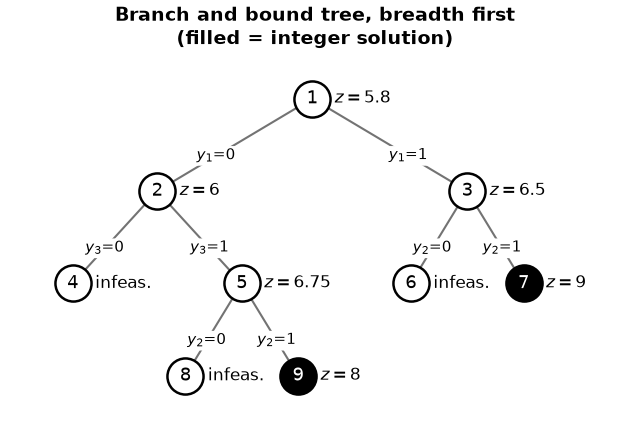

In [6]:
def plot_tree(nodes, edges, ax=None):
    """Draw the branch and bound tree from the node records and edge list."""
    table = {n["node"]: n for n in nodes}

    depth = {1: 0}
    children = {}
    for parent, child, _ in edges:
        depth[child] = depth[parent] + 1
        children.setdefault(parent, []).append(child)

    # tidy layout: leaves get consecutive slots left to right, a parent sits
    # at the midpoint of its children
    x_of = {}
    next_slot = [0.0]

    def place(node_id):
        kids = children.get(node_id, [])
        if not kids:
            x_of[node_id] = next_slot[0]
            next_slot[0] += 1.0
        else:
            for kid in kids:
                place(kid)
            x_of[node_id] = 0.5 * (x_of[kids[0]] + x_of[kids[-1]])

    place(1)
    pos = {node_id: (x_of[node_id], -depth[node_id]) for node_id in depth}

    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 4.5))

    for parent, child, label in edges:
        (x0, y0), (x1, y1) = pos[parent], pos[child]
        ax.plot([x0, x1], [y0, y1], color="0.45", lw=1.5, ls="-", zorder=1)
        ax.annotate(
            label,
            xy=(x0 + 0.62 * (x1 - x0), y0 + 0.62 * (y1 - y0)),
            ha="center",
            va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none"),
            zorder=2,
        )

    for node_id, (x, y) in pos.items():
        record = table[node_id]
        # case 2 nodes (integer solutions) are filled; everything else is open
        filled = record["case"] == 2
        ax.plot(
            x,
            y,
            marker="o",
            ms=26,
            mfc="black" if filled else "white",
            mec="black",
            mew=1.8,
            zorder=3,
        )
        ax.annotate(
            str(node_id),
            xy=(x, y),
            ha="center",
            va="center",
            fontsize=13,
            color="white" if filled else "black",
            zorder=4,
        )
        text = "infeas." if record["z_LP"] is None else f"$z={record['z_LP']:g}$"
        ax.annotate(
            text, xy=(x + 0.20, y), ha="left", va="center", fontsize=12, zorder=4
        )

    ax.set_xlim(min(x_of.values()) - 0.6, max(x_of.values()) + 0.9)
    ax.set_ylim(-max(depth.values()) - 0.5, 0.5)
    ax.axis("off")
    return ax


fig, ax = plt.subplots(figsize=(8.0, 4.8))
plot_tree(nodes, edges, ax=ax)
ax.set_title(
    "Branch and bound tree, breadth first\n(filled = integer solution)", fontsize=14
)
plt.show()

Node 9 is the optimum. Nodes 4, 6 and 8 are infeasible; nodes 7 and 9 are the two integer solutions found,
in that order. The three infeasible leaves and the fathomed subtrees are the $99.99\ldots\%$ the algorithm
skipped — six of the fifteen nodes here, and the difference between minutes and centuries at thirty-five
binaries.

Finally, the sanity check every implementation needs: hand the whole problem to a real MILP solver and
confirm it agrees.

In [7]:
def build_mipex_milp():
    """(MIPEX) with the integrality restored."""
    m = build_mipex_relaxation()
    for j in m.J:
        m.y[j].domain = pyo.Binary
    return m


m = build_mipex_milp()
results = solver_milp.solve(m, load_solutions=False)
assert pyo.check_optimal_termination(
    results
), f"MILP solve failed: {results.solver.termination_condition}"
m.solutions.load_from(results)

print(
    f"HiGHS: z* = {pyo.value(m.z):.0f}, "
    f"y* = {[round(pyo.value(m.y[j])) for j in m.J]}, x* = {pyo.value(m.x):.0f}"
)
assert (
    abs(pyo.value(m.z) - incumbent["z"]) < 1e-6
), "our branch and bound disagrees with HiGHS"

HiGHS: z* = 8, y* = [0, 1, 1], x* = 3


## 2. Outer approximation

Branch and bound needs a relaxation that is cheap to solve. When the continuous part of the problem is
nonlinear, the LP relaxation is gone and something else has to supply the bound. **Outer approximation**
supplies it by linearizing.

The handout states the MINLP as

$$
\begin{aligned}
\min_{x,\,y} \quad & z = c^\top y + f(x) \\
\text{s.t.} \quad & g(x) + By \le 0, \qquad Ay \le a, \qquad x \in X, \qquad y \in \{0,1\}^{q},
\end{aligned}
$$

and alternates two problems:

* the **NLP subproblem**, with $y$ fixed at a guess $y^{k}$. It is a *restriction*, so every solution is
  an implementable design and its value $z^{u}$ is an **upper** bound.
* the **MILP master problem**, in which every nonlinear function is replaced by its first-order Taylor
  expansion at the points $x^{1}, \dots, x^{k}$ visited so far. If $f$ and $g$ are **convex**, each
  tangent plane underestimates the function it replaces, the master's feasible set contains the MINLP's,
  and its value $z^{L}$ is a **lower** bound.

Between iterations an **integer cut** excludes the $y^{k}$ just tried,

$$
\sum_{i \in B^{k}} y_i - \sum_{i \in N^{k}} y_i \le |B^{k}| - 1,
\qquad B^{k} = \{i : y^{k}_i = 1\}, \quad N^{k} = \{i : y^{k}_i = 0\},
$$

and the loop stops when $z^{u} - z^{L} \le \varepsilon$.

**Convexity is not optional.** If $f$ or $g$ is nonconvex a tangent plane can cut into the feasible
region, $z^{L}$ is not a bound, and the method can converge to the wrong answer. The example below is
chosen so that the requirement is satisfied, and we check it.

### The example: multilayer building insulation

A wall separates conditioned interior space from the environment. Heat flows through it at a rate
proportional to the overall heat transfer coefficient $U = 1/R$, where the thermal resistance of $N$
insulating layers adds in series:

$$
R = R_0 + \sum_{n=1}^{N} \frac{x_n}{k_n},
$$

with $x_n$ the thickness of layer $n$ [m], $k_n$ its thermal conductivity [W/m/K], and $R_0$ the
resistance of the structural elements. Annual energy cost is proportional to $U$; installing layer $n$
costs a fixed $a_n$ plus $b_n$ per unit thickness. So with $y_n \in \{0,1\}$ indicating whether layer $n$
is installed at all,

$$
\begin{aligned}
\min_{x,\,y} \quad & \frac{\alpha}{R_0 + \sum_n x_n / k_n}
                     \;+\; \beta \sum_n \left( a_n y_n + b_n x_n \right) \\
\text{s.t.} \quad & x_n \le t_n^{\max} y_n && n = 1, \dots, N \\
                  & \sum_n x_n \le T \\
                  & x_n \ge 0, \qquad y_n \in \{0,1\}.
\end{aligned}
$$

Read it against the handout's form. The fixed installation charges $\beta a_n y_n$ are $c^\top y$; the
energy and material costs are $f(x)$; the rows $x_n \le t_n^{\max} y_n$ are $g(x) + By \le 0$, the
constraints that couple the two kinds of variable; the thickness budget involves $x$ only. There are no
pure-binary rows $Ay \le a$ in this instance.

**$f$ is convex.** $\alpha/R$ is a convex decreasing function of $R > 0$ composed with an affine,
increasing function of $x$, and the rest is linear. Every coupled constraint is already linear. So outer
approximation is on firm ground here — and Ipopt will find the *global* optimum of each NLP subproblem,
not merely a local one.

:::{note}
**Source and licence.** The application, the physical model and the material data are adapted from
*Hands-On Mathematical Optimization with Python* by Postek, Zocca, Gromicho and Kantor (Cambridge
University Press, 2025), notebook 6.4, "Optimal Design of Multilayered Building Insulation". The MO-book
code is MIT-licensed, Copyright (c) 2022 Jeffrey Kantor, and that notice travels with substantial portions
of it. Their notebook solves the problem as a mixed-integer *conic* program with Mosek; here it is written
in the handout's MINLP form and solved by outer approximation, which is a different algorithm reaching the
same answer. The per-layer thickness limits $t_n^{\max}$ and the fifth material are additions of this
course, so that more than one layer is worth installing.
:::

In [8]:
# k: thermal conductivity [W/m/K]; a: fixed installation cost [$/m^2];
# b: installed material cost [$/m^3]; tmax: largest available thickness [m]
materials = pd.DataFrame(
    {
        "Fiberglass batt": {"k": 0.040, "a": 4.0, "b": 60.0, "tmax": 0.06},
        "Mineral wool": {"k": 0.030, "a": 5.0, "b": 150.0, "tmax": 0.06},
        "Rigid foam (low R)": {"k": 0.030, "a": 8.0, "b": 120.0, "tmax": 0.05},
        "Rigid foam (high R)": {"k": 0.015, "a": 8.0, "b": 180.0, "tmax": 0.05},
        "Aerogel blanket": {"k": 0.013, "a": 12.0, "b": 900.0, "tmax": 0.02},
    }
).T

ALPHA = 60.0  # annualized energy cost per unit U   [$ K / W / m^2]
BETA = 0.05  # equivalent annual cost factor on capital
R0 = 2.0  # resistance of the structural elements  [m^2 K / W]
T_TOTAL = 0.15  # total thickness the wall cavity allows [m]

display(materials)

,k,a,b,tmax
Fiberglass batt,0.040,4.0,60.0,0.06
Mineral wool,0.030,5.0,150.0,0.06
Rigid foam (low R),0.030,8.0,120.0,0.05
Rigid foam (high R),0.015,8.0,180.0,0.05
Aerogel blanket,0.013,12.0,900.0,0.02


Two derived quantities explain most of the answer in advance. A material's **cost per unit of thermal
resistance** is $b_n k_n$, and its **resistance per unit thickness** is $1/k_n$. Cheapest is not thinnest,
which is exactly why the problem is interesting: the thickness budget $T$ forces a trade.

In [9]:
economics = pd.DataFrame(
    {
        "cost per unit R  [$ W / K]": materials["b"] * materials["k"],
        "R per unit thickness  [K/W/m]": 1.0 / materials["k"],
        "fixed charge  [$/m^2/yr]": BETA * materials["a"],
    }
)
display(economics.round(2))

,cost per unit R [$ W / K],R per unit thickness [K/W/m],fixed charge [$/m^2/yr]
Fiberglass batt,2.4,25.00,0.20
Mineral wool,4.5,33.33,0.25
Rigid foam (low R),3.6,33.33,0.40
Rigid foam (high R),2.7,66.67,0.40
Aerogel blanket,11.7,76.92,0.60


In [10]:
def thermal_resistance(x):
    """R = R0 + sum_n x_n / k_n for a dict of thicknesses."""
    return R0 + sum(x[n] / materials.loc[n, "k"] for n in materials.index)


def f_continuous(x):
    """The nonlinear part of the objective, f(x): energy cost plus material cost."""
    return ALPHA / thermal_resistance(x) + BETA * sum(
        materials.loc[n, "b"] * x[n] for n in materials.index
    )


def grad_f_continuous(x):
    """Gradient of f at x. d/dx_n [alpha / R] = -alpha / R^2 / k_n."""
    R = thermal_resistance(x)
    return {
        n: -ALPHA / R**2 / materials.loc[n, "k"] + BETA * materials.loc[n, "b"]
        for n in materials.index
    }

### The NLP subproblem: fix $y$, get an upper bound

In [11]:
def build_nlp_subproblem(y):
    """NLP subproblem of outer approximation: the design cost with the layers y fixed.

    Arguments:
        y: dict mapping material name to 0 or 1

    Returns:
        a Pyomo ConcreteModel
    """
    m = pyo.ConcreteModel("insulation NLP subproblem")
    m.N = pyo.Set(initialize=list(materials.index))
    m.x = pyo.Var(m.N, domain=pyo.NonNegativeReals, bounds=(0, T_TOTAL))

    @m.Constraint(m.N)
    def layer_available(m, n):
        return m.x[n] <= materials.loc[n, "tmax"] * y[n]

    @m.Constraint()
    def thickness_budget(m):
        return sum(m.x[n] for n in m.N) <= T_TOTAL

    @m.Objective(sense=pyo.minimize)
    def cost(m):
        R = R0 + sum(m.x[n] / materials.loc[n, "k"] for n in m.N)
        return (
            ALPHA / R
            + BETA * sum(materials.loc[n, "b"] * m.x[n] for n in m.N)
            + BETA
            * sum(materials.loc[n, "a"] * y[n] for n in m.N)  # c^T y, a constant here
        )

    return m


def solve_nlp_subproblem(y):
    """Solve the NLP subproblem and return (x^k, z^u)."""
    m = build_nlp_subproblem(y)
    results = solver_nlp.solve(m)
    assert pyo.check_optimal_termination(
        results
    ), f"NLP subproblem failed for y = {y}: {results.solver.termination_condition}"
    return {n: pyo.value(m.x[n]) for n in materials.index}, pyo.value(m.cost)

### The MILP master problem: linearize, get a lower bound

The master problem carries **one copy of the linearized objective row for every point visited so far**,
not just the latest. That accumulation is what makes $z^{L}$ increase monotonically and the method
terminate: each new NLP solution adds a tangent plane that cuts off the design just tried.

In [12]:
def build_master_problem(points, tried):
    """MILP master problem of outer approximation.

    Arguments:
        points: list of x^k dicts, one per iteration so far -- the linearization points
        tried:  list of y^k dicts already evaluated, each excluded by an integer cut

    Returns:
        a Pyomo ConcreteModel
    """
    m = pyo.ConcreteModel("outer approximation master MILP")
    m.N = pyo.Set(initialize=list(materials.index))
    m.x = pyo.Var(m.N, domain=pyo.NonNegativeReals, bounds=(0, T_TOTAL))
    m.y = pyo.Var(m.N, domain=pyo.Binary)
    m.epi = pyo.Var(domain=pyo.Reals)  # the epigraph variable, alpha in the handout

    @m.Constraint(m.N)
    def layer_available(m, n):
        return m.x[n] <= materials.loc[n, "tmax"] * m.y[n]

    @m.Constraint()
    def thickness_budget(m):
        return sum(m.x[n] for n in m.N) <= T_TOTAL

    # one outer approximation of the objective per point visited: since f is convex,
    # every tangent plane lies below f, so each row is a valid relaxation
    m.outer_approximation = pyo.ConstraintList()
    for xk in points:
        fk = f_continuous(xk)
        gk = grad_f_continuous(xk)
        m.outer_approximation.add(
            m.epi
            >= BETA * sum(materials.loc[n, "a"] * m.y[n] for n in m.N)
            + fk
            + sum(gk[n] * (m.x[n] - xk[n]) for n in m.N)
        )

    # integer cuts: at least one component of y must differ from each y^k already tried
    m.integer_cuts = pyo.ConstraintList()
    for yk in tried:
        ones = [n for n in m.N if yk[n] > 0.5]
        zeros = [n for n in m.N if yk[n] <= 0.5]
        m.integer_cuts.add(
            sum(m.y[n] for n in ones) - sum(m.y[n] for n in zeros) <= len(ones) - 1
        )

    @m.Objective(sense=pyo.minimize)
    def lower_bound(m):
        return m.epi

    return m

### The loop

Start from a deliberately poor guess: aerogel alone. It has the highest resistance per unit thickness of
anything in the table and by far the highest cost per unit of resistance — the kind of specification a
catalogue leads you to and an optimizer talks you out of.

In [13]:
def outer_approximation(y_start, eps=1e-4, max_iter=20, verbose=True):
    """Outer approximation for the insulation MINLP, following the handout's flowchart.

    Arguments:
        y_start: dict of initial binary values
        eps: gap tolerance on z^u - z^L
        max_iter: iteration cap, purely a safety net

    Returns:
        history DataFrame, and the best (y, x, cost) found
    """
    y = dict(y_start)
    points, tried, history = [], [], []
    z_upper, best = np.inf, None
    z_lower = -np.inf

    for k in range(1, max_iter + 1):
        # --- NLP subproblem: a feasible design, hence an upper bound
        xk, z_nlp = solve_nlp_subproblem(y)
        if z_nlp < z_upper:
            z_upper, best = z_nlp, (dict(y), dict(xk))
        points.append(xk)
        tried.append(dict(y))

        # --- MILP master problem: a relaxation, hence a lower bound
        master = build_master_problem(points, tried)
        results = solver_milp.solve(master, load_solutions=False)
        if not pyo.check_optimal_termination(results):
            # every binary point has been cut off: nothing left to try
            assert (
                results.solver.termination_condition
                == pyo.TerminationCondition.infeasible
            ), f"master problem failed: {results.solver.termination_condition}"
            history.append(
                {
                    "iteration": k,
                    "z_nlp": z_nlp,
                    "z_upper": z_upper,
                    "z_lower": z_lower,
                    "layers": sum(y.values()),
                }
            )
            if verbose:
                print(f"iteration {k}: master infeasible -- search exhausted")
            break
        master.solutions.load_from(results)
        z_lower = pyo.value(master.lower_bound)

        history.append(
            {
                "iteration": k,
                "z_nlp": z_nlp,
                "z_upper": z_upper,
                "z_lower": z_lower,
                "layers": sum(y.values()),
            }
        )
        if verbose:
            print(
                f"iteration {k}: z^u = {z_upper:8.4f}   z^L = {z_lower:8.4f}   "
                f"gap = {z_upper - z_lower:8.4f}   "
                f"y = {[int(round(y[n])) for n in materials.index]}"
            )

        if z_upper - z_lower <= eps:
            break

        y = {n: round(pyo.value(master.y[n])) for n in materials.index}

    return pd.DataFrame(history).set_index("iteration"), best, z_upper


y_start = {n: (1 if n == "Aerogel blanket" else 0) for n in materials.index}
history, best, oa_cost = outer_approximation(y_start)

iteration 1: z^u =  18.4565   z^L =  -8.2708   gap =  26.7273   y = [0, 0, 0, 0, 1]


iteration 2: z^u =   9.6981   z^L =   9.0593   gap =   0.6387   y = [0, 1, 1, 1, 1]


iteration 3: z^u =   9.0700   z^L =   9.0981   gap =  -0.0281   y = [1, 1, 0, 1, 0]


In [14]:
display(history.round(4))

y_best, x_best = best
solution = materials.copy()
solution["installed"] = [int(y_best[n]) for n in materials.index]
solution["x opt [m]"] = [max(x_best[n], 0.0) for n in materials.index]
display(solution[["k", "a", "b", "tmax", "installed", "x opt [m]"]].round(5))

print(f"optimal annualized cost = {oa_cost:0.4f} $/m^2")
print(
    f"total thickness         = {sum(max(v, 0.0) for v in x_best.values()):0.4f} m "
    f"(budget {T_TOTAL} m)"
)
print(f"overall resistance R    = {thermal_resistance(x_best):0.3f} m^2 K / W")

,z_nlp,z_upper,z_lower,layers
iteration,,,,
1,18.4565,18.4565,-8.2708,1
2,9.6981,9.6981,9.0593,4
3,9.0700,9.0700,9.0981,3


,k,a,b,tmax,installed,x opt [m]
Fiberglass batt,0.040,4.0,60.0,0.06,1,0.04
Mineral wool,0.030,5.0,150.0,0.06,1,0.06
Rigid foam (low R),0.030,8.0,120.0,0.05,0,0.00
Rigid foam (high R),0.015,8.0,180.0,0.05,1,0.05
Aerogel blanket,0.013,12.0,900.0,0.02,0,0.00


optimal annualized cost = 9.0700 $/m^2
total thickness         = 0.1500 m (budget 0.15 m)
overall resistance R    = 8.333 m^2 K / W


Three iterations. Read the bounds column by column:

* **Iteration 1** evaluates the aerogel-only design. It is feasible, so $z^{u}$ is an honest upper bound —
  and an expensive one. The master problem, holding a single tangent plane, returns a lower bound far
  below anything achievable: one linearization is a very weak relaxation.
* **Iteration 2** jumps to a much better design. The lower bound leaps, because the master now has two
  tangent planes and an integer cut.
* **Iteration 3** finds the optimum, and the master's value rises above the incumbent, closing the gap.

That the lower bound ends up slightly *above* the upper bound is not a bug. The integer cuts have removed
every design already evaluated, so $z^{L}$ is a bound on the designs **not yet tried** — and once that
exceeds the best design in hand, nothing untried can beat it. The search is over. BGW report convergence
in 3 to 5 iterations typically, and in no more than two when $f$ and $g$ are linear; this is a
five-binary problem with 32 possible designs, settled in three NLPs and three MILPs.

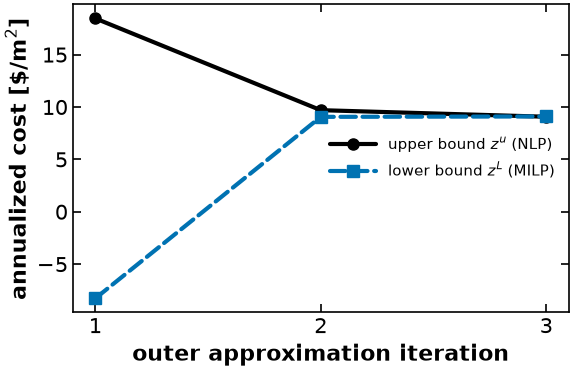

In [15]:
fig, ax = plt.subplots(figsize=(6.4, 4))

ax.plot(history.index, history["z_upper"], marker="o", label=r"upper bound $z^u$ (NLP)")
ax.plot(
    history.index, history["z_lower"], marker="s", label=r"lower bound $z^L$ (MILP)"
)

ax.set_xlabel("outer approximation iteration")
ax.set_ylabel("annualized cost [\\$/m$^2$]")
ax.set_xticks(history.index)
ax.legend(loc="center right", fontsize=11)
plt.show()

The two bounds close on the answer from opposite sides. That picture is the one to keep: it is what a
MINLP solver log is telling you, and a gap that has not closed means the number on the screen is not yet
an answer.

### Checking against a real MINLP solver

Bonmin implements outer approximation and NLP-based branch and bound. Handing it the same model is the
check on everything above — and, in practice, what you would actually do.

In [16]:
def build_insulation_minlp():
    """The full MINLP, for a solver that can take it whole."""
    m = pyo.ConcreteModel("insulation MINLP")
    m.N = pyo.Set(initialize=list(materials.index))
    m.x = pyo.Var(m.N, domain=pyo.NonNegativeReals, bounds=(0, T_TOTAL))
    m.y = pyo.Var(m.N, domain=pyo.Binary)

    @m.Constraint(m.N)
    def layer_available(m, n):
        return m.x[n] <= materials.loc[n, "tmax"] * m.y[n]

    @m.Constraint()
    def thickness_budget(m):
        return sum(m.x[n] for n in m.N) <= T_TOTAL

    @m.Objective(sense=pyo.minimize)
    def cost(m):
        R = R0 + sum(m.x[n] / materials.loc[n, "k"] for n in m.N)
        return ALPHA / R + BETA * sum(
            materials.loc[n, "a"] * m.y[n] + materials.loc[n, "b"] * m.x[n] for n in m.N
        )

    return m


m_minlp = build_insulation_minlp()
results = pyo.SolverFactory("bonmin").solve(m_minlp)
assert pyo.check_optimal_termination(
    results
), f"bonmin failed: {results.solver.termination_condition}"

print(f"bonmin: cost = {pyo.value(m_minlp.cost):0.4f} $/m^2")
print("        layers = " f"{[n for n in m_minlp.N if pyo.value(m_minlp.y[n]) > 0.5]}")
assert (
    abs(pyo.value(m_minlp.cost) - oa_cost) < 1e-3
), "our outer approximation disagrees with bonmin"

bonmin: cost = 9.0700 $/m^2
        layers = ['Fiberglass batt', 'Mineral wool', 'Rigid foam (high R)']


Same answer, to four decimals.

## 3. Generalized Benders decomposition

Outer approximation has one obvious cost. The master problem grows by an entire block of linearized rows
at every iteration — one for the objective and one for **each component** of $g$. After a dozen iterations
of a problem with a hundred inequalities, the MILP is carrying more than a thousand extra rows, and it
still carries a full copy of the continuous variables $x$.

**Generalized Benders decomposition** (GBD) keeps the outer loop of §2 exactly as it is — same NLP
subproblem, same convergence test, same integer cuts — and replaces that whole block with a *single*
inequality per iteration, in $y$ alone.

The handout's master problem is

$$
\begin{aligned}
z^{L} = \min_{y,\,\alpha} \quad & \alpha \\
\text{s.t.} \quad & \alpha \ \ge \ c^\top y + f(x^{k}) + u^{k\top}\!\left[\, g(x^{k}) + B y \,\right],
  \qquad k = 1,\dots,K \\
& Ay \le a, \qquad y \in \{0,1\}^{q}, \qquad \alpha \in \mathbb{R}.
\end{aligned}
$$

Everything on the right except $y$ is a number the NLP subproblem already produced. The one new
ingredient is $u^{k} \ge 0$: the **multipliers of the coupled inequalities** $g(x) + B y^{k} \le 0$ at the
NLP solution.

### Why a fixed-$y$ solve says anything about other $y$

Because the multipliers carry the sensitivity. For a convex problem the Lagrangian

$$
L(x, y) \;=\; c^\top y + f(x) + u^{k\top}\!\left[\, g(x) + B y \,\right]
$$

underestimates the objective at *every* feasible $(x,y)$, and $x^{k}$ minimizes the $y$-independent part
$f(x) + u^{k\top} g(x)$ over $X$ — that is exactly what the subproblem's KKT conditions say. So replacing
$x$ by $x^{k}$ costs nothing, and the resulting inequality is a valid lower bound on the objective for
**every** $y$ at once. One NLP solve, one cut, no $x$.

For the insulation problem the coupled rows are the availability constraints $x_n - t^{\max}_n y_n \le 0$,
so $g(x)_n = x_n$ and $B = -\operatorname{diag}(t^{\max})$, and the cut reads

$$
\alpha \ \ge \ \beta \sum_n a_n y_n \;+\; f(x^{k}) \;+\; \sum_n u^{k}_n \left( x^{k}_n - t^{\max}_n y_n \right).
$$

### The subproblem, now returning multipliers

Same NLP as §2. The only change is a `Suffix` asking Ipopt to send the duals back.

:::{warning}
**Check the sign.** Pyomo returns Ipopt's duals in its own convention, and for a `<=` row in a
minimization they come back **non-positive**. The handout's $u^{k}$ is non-negative, so we negate. Do not
take this on faith — the cell after this one *verifies* the convention by checking that the cut is tight
at $y^{k}$, which it can only be if the sign is right.
:::

In [17]:
def solve_nlp_subproblem_with_duals(y):
    """Solve the OA/GBD NLP subproblem and also return the multipliers of the coupled rows.

    Arguments:
        y: dict mapping material name to 0 or 1

    Returns:
        (x^k, z^u, u^k) -- thicknesses, objective, and the non-negative multipliers of
        the availability constraints x_n <= tmax_n y_n
    """
    m = build_nlp_subproblem(y)
    m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)

    results = solver_nlp.solve(m)
    assert pyo.check_optimal_termination(
        results
    ), f"NLP subproblem failed for y = {y}: {results.solver.termination_condition}"

    xk = {n: pyo.value(m.x[n]) for n in materials.index}
    # Pyomo/Ipopt hands back non-positive duals for "<=" rows in a minimization;
    # the handout's u^k is non-negative, so flip the sign.
    uk = {n: -m.dual[m.layer_available[n]] for n in materials.index}
    return xk, pyo.value(m.cost), uk

The check. At $y = y^{k}$ every term $u^{k}_n (x^{k}_n - t^{\max}_n y^{k}_n)$ is a complementarity
product, so the sum is zero and the cut collapses to $\alpha \ge c^\top y^{k} + f(x^{k}) = z^{u}_{k}$: the
Benders cut passes exactly through the point the NLP just found. If the sign were flipped, this identity
would fail loudly.

In [18]:
xk0, zk0, uk0 = solve_nlp_subproblem_with_duals(y_start)

print("multipliers u^1 (all should be >= 0):")
for n in materials.index:
    print(f"  {n:22s} {uk0[n]:10.3f}")

complementarity = sum(
    uk0[n] * (xk0[n] - materials.loc[n, "tmax"] * y_start[n]) for n in materials.index
)
cut_at_yk = (
    BETA * sum(materials.loc[n, "a"] * y_start[n] for n in materials.index)
    + f_continuous(xk0)
    + complementarity
)

print(
    f"\nsum u_n (x_n - tmax_n y_n) = {complementarity:.3e}   (zero by complementarity)"
)
print(f"cut evaluated at y^1       = {cut_at_yk:.6f}")
print(f"NLP objective z^u_1        = {zk0:.6f}")

assert (
    min(uk0.values()) >= -1e-8
), "a multiplier came back negative -- sign convention is wrong"
assert (
    abs(cut_at_yk - zk0) < 1e-4
), "the Benders cut is not tight at y^k -- check the sign convention"

multipliers u^1 (all should be >= 0):
  Fiberglass batt           118.233
  Mineral wool              153.638
  Rigid foam (low R)        155.138
  Rigid foam (high R)       311.866
  Aerogel blanket           323.620

sum u_n (x_n - tmax_n y_n) = 1.049e-05   (zero by complementarity)
cut evaluated at y^1       = 18.456522
NLP objective z^u_1        = 18.456511


### The master problem

Compare this with `build_master_problem` above. There is no `m.x` at all, no `layer_available`, no
`thickness_budget` — the continuous variables have been **eliminated**, and each NLP solve contributes one
row instead of $1 + r$. The integer cuts are identical to §2.

In [19]:
def build_gbd_master(cuts, tried):
    """MILP master problem of generalized Benders decomposition.

    Arguments:
        cuts:  list of (x^k, u^k) pairs, one per iteration so far
        tried: list of y^k dicts already evaluated, each excluded by an integer cut

    Returns:
        a Pyomo ConcreteModel
    """
    m = pyo.ConcreteModel("generalized Benders master MILP")
    m.N = pyo.Set(initialize=list(materials.index))
    m.y = pyo.Var(m.N, domain=pyo.Binary)
    m.epi = pyo.Var(domain=pyo.Reals)  # the epigraph variable, alpha in the handout

    # one Lagrangian (Benders) cut per NLP solved: a single row, in y only
    m.benders_cuts = pyo.ConstraintList()
    for xk, uk in cuts:
        m.benders_cuts.add(
            m.epi
            >= BETA * sum(materials.loc[n, "a"] * m.y[n] for n in m.N)
            + f_continuous(xk)
            + sum(uk[n] * (xk[n] - materials.loc[n, "tmax"] * m.y[n]) for n in m.N)
        )

    # integer cuts: identical to the outer approximation master problem
    m.integer_cuts = pyo.ConstraintList()
    for yk in tried:
        ones = [n for n in m.N if yk[n] > 0.5]
        zeros = [n for n in m.N if yk[n] <= 0.5]
        m.integer_cuts.add(
            sum(m.y[n] for n in ones) - sum(m.y[n] for n in zeros) <= len(ones) - 1
        )

    @m.Objective(sense=pyo.minimize)
    def lower_bound(m):
        return m.epi

    return m

### The loop

Structurally identical to `outer_approximation`. Start from the same deliberately poor guess — aerogel
alone — so that the two methods are compared from the same place.

In [20]:
def generalized_benders(y_start, eps=1e-4, max_iter=20, verbose=True):
    """Generalized Benders decomposition for the insulation MINLP.

    Arguments:
        y_start: dict of initial binary values
        eps: gap tolerance on z^u - z^L
        max_iter: iteration cap, purely a safety net

    Returns:
        history DataFrame, the best (y, x) found, and its cost
    """
    y = dict(y_start)
    cuts, tried, history = [], [], []
    z_upper, best = np.inf, None
    z_lower = -np.inf

    for k in range(1, max_iter + 1):
        # --- NLP subproblem: a feasible design, hence an upper bound, plus multipliers
        xk, z_nlp, uk = solve_nlp_subproblem_with_duals(y)
        if z_nlp < z_upper:
            z_upper, best = z_nlp, (dict(y), dict(xk))
        cuts.append((xk, uk))
        tried.append(dict(y))

        # --- MILP master problem: a relaxation, hence a lower bound
        master = build_gbd_master(cuts, tried)
        results = solver_milp.solve(master, load_solutions=False)
        if not pyo.check_optimal_termination(results):
            # every binary point has been cut off: nothing left to try
            assert (
                results.solver.termination_condition
                == pyo.TerminationCondition.infeasible
            ), f"master problem failed: {results.solver.termination_condition}"
            history.append(
                {
                    "iteration": k,
                    "z_nlp": z_nlp,
                    "z_upper": z_upper,
                    "z_lower": z_lower,
                }
            )
            if verbose:
                print(f"iteration {k}: master infeasible -- search exhausted")
            break
        master.solutions.load_from(results)
        z_lower = pyo.value(master.lower_bound)

        history.append(
            {"iteration": k, "z_nlp": z_nlp, "z_upper": z_upper, "z_lower": z_lower}
        )
        if verbose:
            print(
                f"iteration {k}: z^u = {z_upper:8.4f}   z^L = {z_lower:8.4f}   "
                f"gap = {z_upper - z_lower:8.4f}   "
                f"y = {[int(round(y[n])) for n in materials.index]}"
            )

        if z_upper - z_lower <= eps:
            break

        y = {n: round(pyo.value(master.y[n])) for n in materials.index}

    return pd.DataFrame(history).set_index("iteration"), best, z_upper


gbd_history, gbd_best, gbd_cost = generalized_benders(y_start)

iteration 1: z^u =  18.4565   z^L = -19.9559   gap =  38.4124   y = [0, 0, 0, 0, 1]


iteration 2: z^u =   9.8981   z^L =   8.7231   gap =   1.1750   y = [1, 1, 1, 1, 1]


iteration 3: z^u =   9.8981   z^L =   8.9731   gap =   0.9250   y = [1, 0, 0, 1, 0]


iteration 4: z^u =   9.0700   z^L =   9.0752   gap =  -0.0052   y = [1, 1, 0, 1, 0]


In [21]:
display(gbd_history.round(4))

print(f"GBD optimal annualized cost = {gbd_cost:0.4f} $/m^2")
print(f"layers = {[n for n in materials.index if gbd_best[0][n] > 0.5]}")

assert abs(gbd_cost - oa_cost) < 1e-3, "GBD and outer approximation disagree"
assert abs(gbd_cost - pyo.value(m_minlp.cost)) < 1e-3, "GBD disagrees with bonmin"

,z_nlp,z_upper,z_lower
iteration,,,
1,18.4565,18.4565,-19.9559
2,9.8981,9.8981,8.7231
3,10.0105,9.8981,8.9731
4,9.0700,9.0700,9.0752


GBD optimal annualized cost = 9.0700 $/m^2
layers = ['Fiberglass batt', 'Mineral wool', 'Rigid foam (high R)']


**Four iterations, against outer approximation's three**, and the same optimum, $9.0700\ \$/\mathrm{m}^2$
with the same three layers. That is not a coincidence of this data set: it is precisely what BGW report on
their own convex test problem (Figure A.11), where OA takes three major iterations and GBD takes four,
with visibly weaker lower bounds throughout.

Read the extra iteration off the table. GBD's iteration 3 evaluates a design worth $10.0105$ — *worse*
than the incumbent it already holds. Outer approximation never proposes that design, because its master
problem knows enough about $x$ to see that the design cannot pay. GBD's master problem, having eliminated
$x$, does not.

### The bound inequality, checked

The handout claims something stronger than "GBD is usually slower":

$$
z^{L}_{\text{GBD}} \ \le \ z^{L}_{\text{OA}} \ \le \ z^{*}
\qquad \text{at every iteration.}
$$

The reason is that the Benders cut is a **surrogate** of the outer approximation cuts — one non-negative
combination of them, with $u^{k}$ as the weights. Adding valid inequalities together is always legal and
almost always loses information.

The two runs above cannot test that directly, because after iteration 1 they visit different designs.
So here is a controlled experiment: drive the sequence of $y$'s with the outer approximation master, and at
each step build *both* master problems from the *same* linearization points and the *same* integer cuts.
Any difference in $z^{L}$ is then attributable to the cut form alone.

In [22]:
def compare_bounds(y_start, n_iter=4):
    """Build both master problems from identical data and compare their lower bounds."""
    y = dict(y_start)
    points, cuts, tried, rows = [], [], [], []

    for k in range(1, n_iter + 1):
        xk, _, uk = solve_nlp_subproblem_with_duals(y)
        points.append(xk)
        cuts.append((xk, uk))
        tried.append(dict(y))

        oa_master = build_master_problem(points, tried)
        gbd_master = build_gbd_master(cuts, tried)

        res_oa = solver_milp.solve(oa_master, load_solutions=False)
        res_gbd = solver_milp.solve(gbd_master, load_solutions=False)
        if not (
            pyo.check_optimal_termination(res_oa)
            and pyo.check_optimal_termination(res_gbd)
        ):
            break
        oa_master.solutions.load_from(res_oa)
        gbd_master.solutions.load_from(res_gbd)

        rows.append(
            {
                "iteration": k,
                "z_lower OA": pyo.value(oa_master.lower_bound),
                "z_lower GBD": pyo.value(gbd_master.lower_bound),
            }
        )
        # the OA master drives the sequence, so both see the same designs
        y = {n: round(pyo.value(oa_master.y[n])) for n in materials.index}

    out = pd.DataFrame(rows).set_index("iteration")
    out["OA stronger by"] = out["z_lower OA"] - out["z_lower GBD"]
    return out


bounds = compare_bounds(y_start)
display(bounds.round(4))

assert (
    bounds["OA stronger by"] >= -1e-6
).all(), "the OA >= GBD bound inequality failed"
print("z_GBD^L <= z_OA^L at every iteration, as the handout claims.")

,z_lower OA,z_lower GBD,OA stronger by
iteration,,,
1,-8.2708,-19.9559,11.6851
2,9.0593,8.6894,0.3699
3,9.0981,8.8700,0.2281
4,9.1720,8.8700,0.3020


z_GBD^L <= z_OA^L at every iteration, as the handout claims.


Both bounds are valid; OA's is never worse, and on the first iteration it is worse by more than $11$ —
the difference between a master problem that still knows what $x$ costs and one that has projected $x$
out. Plotting the two runs side by side gives the same picture BGW's Figure A.11 does.

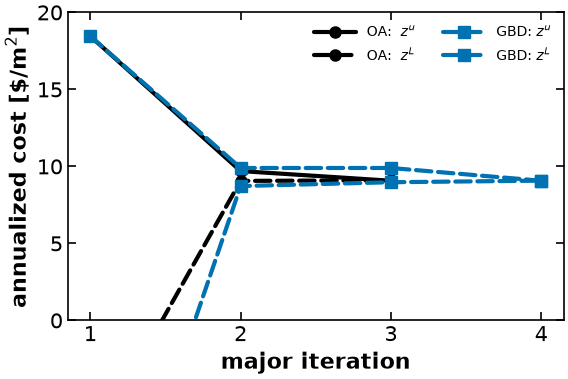

In [23]:
fig, ax = plt.subplots(figsize=(6.4, 4))

ax.plot(history.index, history["z_upper"], marker="o", color="C0", label="OA:  $z^u$")
ax.plot(
    history.index,
    history["z_lower"],
    marker="o",
    linestyle="--",
    color="C0",
    label="OA:  $z^L$",
)
ax.plot(
    gbd_history.index,
    gbd_history["z_upper"],
    marker="s",
    color="C1",
    label="GBD: $z^u$",
)
ax.plot(
    gbd_history.index,
    gbd_history["z_lower"],
    marker="s",
    linestyle="--",
    color="C1",
    label="GBD: $z^L$",
)

ax.set_xlabel("major iteration")
ax.set_ylabel("annualized cost [\\$/m$^2$]")
ax.set_xticks(gbd_history.index)
ax.set_ylim(0, 20)  # iteration 1 lower bounds are far below; clip to show the endgame
ax.legend(loc="upper right", fontsize=10, ncol=2)
plt.show()

### Which one to reach for

|  | **Outer approximation** | **Generalized Benders** |
| --- | --- | --- |
| rows added per iteration | $1 + r$ | $1$ |
| continuous variables in the master | $x$ retained | $x$ eliminated |
| master problem | MILP | MILP, much smaller |
| lower bound $z^L$ | **stronger** | weaker |
| major iterations | fewer (3 here) | more (4 here) |

The trade is a cheaper master problem for a weaker bound, and therefore more iterations — each of which
costs an NLP solve, usually the expensive part. GBD is attractive when $r$ is large and the NLP is cheap;
OA when the NLP dominates. Both are exact for convex MINLPs, and neither is for anything else.

## What is not implemented here, and why

**Cutting planes and branch and cut** (handout §2–3) get no cell in this notebook, deliberately. A pure
cutting-plane method is not something you would ever run: successive cuts are derived from a tableau that
already contains the previous cuts, the coefficients grow, the rows become near-parallel, and after enough
rounds the "cut" being added is numerical noise that can slice off genuinely feasible points. The fix — a
bounded number of cut rounds *at each node* of the branch-and-bound tree — is branch and cut, and it is
already running inside every solve above. `appsi_highs` generated cuts on the MIPEX model in §1 and on
every master problem in §2 and §3, without being asked.

**Where the two exact methods stop working.** Both rest on the same property, and it is worth saying
plainly which one.

**Branch and bound** needs the relaxation to be a *valid bound*. Relaxing integrality always is, so §1 is
safe for any MILP.

**Outer approximation and generalized Benders** need $f$ and $g$ to be **convex**, so that a tangent plane
underestimates and the Lagrangian bound holds. That held here, and it was checked rather than assumed.
When it does not hold — a concave cost correlation, a bilinear mixing term — a tangent plane can slice
through the feasible region, the "lower bound" is not a bound, and the method can terminate on the wrong
design while reporting a closed gap. DICOPT's augmented-penalty variant keeps going on nonconvex problems,
but it gives up the guarantee to do so.

That is the subject of the next notebook, [](../8/Global-Opt.ipynb), where the relaxation is built to be
valid *without* assuming convexity, and the branching moves from the binaries to the continuous variables.

## What you would actually run

Everything above is written out longhand so that the mechanism is visible. In practice you call a solver
that implements it. Pyomo ships one: **MindtPy**, `pyo.SolverFactory("mindtpy")`, whose `strategy=`
argument selects outer approximation, the extended cutting plane method, global outer approximation, or a
feasibility pump — the same algorithms, industrially hardened.

```python
results = pyo.SolverFactory("mindtpy").solve(
    m, strategy="OA", mip_solver="appsi_highs", nlp_solver="ipopt"
)
```

Assignment **Algorithms 6** is built entirely on that one line: you toggle `strategy=` and the options
around it, and explain the iteration counts, run times and answers that come back using the theory in this
notebook. Two of the differences you will find are already visible above — a weaker bound costs iterations,
and a method that never proves a bound never proves optimality.

## Further reading

* Handout: *Integer Programming Algorithms*, and the companion notebook [](../8/MILP.ipynb).
* Biegler, Grossmann & Westerberg (1997), Appendix A: §A.3.2 pp. 757–761 for branch and bound, including
  problem (MIPEX) and Figure A.10; §A.3.4 pp. 763–768 for outer approximation, the integer cut, the
  infeasible-subproblem variant, and the convexity requirement.
* Biegler (2010), §1.3 p. 6, on why NLP algorithms are components of MINLP strategies; §11.1 p. 325 for
  the bilevel structure of §2.
* Duran & Grossmann (1986) for outer approximation; Geoffrion (1972) for generalized Benders
  decomposition; Nemhauser & Wolsey (1988) for branch and bound and cutting planes.
* Biegler, Grossmann & Westerberg (1997), §A.3.4 pp. 766–768: master problem (MGB), Figure A.11, and the
  proof sketch that the Benders cut is a surrogate of the outer approximation cuts (Quesada & Grossmann,
  1992) — the source for §3.
* [MindtPy documentation](https://pyomo.readthedocs.io/en/stable/explanation/solvers/mindtpy.html), and
  assignment **Algorithms 6**, which drives it.
* Postek, Zocca, Gromicho & Kantor, *Hands-On Mathematical Optimization with Python*, Cambridge University
  Press (2025), notebook 6.4, for the insulation application and data.